In [ ]:
!git clone https://github.com/CheckNanbang/2025-weather-data-contest.git
# !git pull

Cloning into '2025-weather-data-contest'...
remote: Enumerating objects: 606, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 606 (delta 80), reused 87 (delta 44), pack-reused 462 (from 2)
Receiving objects: 100% (606/606), 106.55 MiB | 16.23 MiB/s, done.
Resolving deltas: 100% (281/281), done.


In [ ]:
%cd 2025-weather-data-contest/

/content/2025-weather-data-contest


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 17.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings("ignore")
from preproccesor import WeatherDataPreprocessor

plt.style.available
sns.color_palette("pastel")
sns.set(palette='pastel')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1: 데이터 로드 및 전처리

# 데이터 로드
df_train = pd.read_csv('/content/drive/MyDrive/2025 날씨 공모전/weather_data_imputed2.csv')
df_test = pd.read_csv('/content/drive/MyDrive/2025 날씨 공모전/non_null_test_data_dh.csv')

# WeatherDataPreprocessor 실행 (기존 코드)
preprocessor = WeatherDataPreprocessor()
cluster_results = preprocessor.preprocess_data(df_train, is_test=False)
cluster_results_test = preprocessor.preprocess_data(df_test, is_test=True)

데이터 전처리 시작...
cluster2_summer 전처리 중...
cluster2_non_summer 전처리 중...
cluster1_summer 전처리 중...
cluster1_non_summer 전처리 중...
cluster0 전처리 중...
cluster3 전처리 중...
클러스터별 데이터 전처리 완료!
데이터 전처리 시작...
cluster2_summer 전처리 중...
cluster2_non_summer 전처리 중...
cluster1_summer 전처리 중...
cluster1_non_summer 전처리 중...
cluster0 전처리 중...
cluster3 전처리 중...
클러스터별 데이터 전처리 완료!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings("ignore")

def calculate_sample_weights(y_values, weight_type='log1p'):
    """
    샘플 가중치 계산 함수

    Parameters:
    - y_values: 타겟 값들
    - weight_type: 가중치 계산 방법
        - 'log1p': log(1+y) - 로그 스케일로 선형 증가
        - 'linear': y 값 자체 사용 (정규화됨)
        - 'sqrt': sqrt(y) - 제곱근 스케일
        - 'quadratic': y^2 - 제곱 스케일 (더 극단적)
    """
    y_values = np.array(y_values)

    if weight_type == 'log1p':
        weights = np.log1p(y_values)  # log(1+y)
    elif weight_type == 'linear':
        weights = y_values
    elif weight_type == 'sqrt':
        weights = np.sqrt(np.maximum(y_values, 0))  # 음수 방지
    elif weight_type == 'quadratic':
        weights = np.square(y_values)
    else:
        raise ValueError("weight_type must be one of: 'log1p', 'linear', 'sqrt', 'quadratic'")

    # 가중치 정규화 (평균을 1로)
    weights = weights / np.mean(weights)

    return weights

def prepare_features(train_df, val_df, target_col, encoder=None):
    """피처 준비 및 인코딩"""
    # 범주형 변수 원핫 인코딩 (branch_id 포함)
    object_cols = train_df.select_dtypes(include="object").columns.tolist()

    if encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        if object_cols:
            encoder.fit(train_df[object_cols])

    if object_cols:
        X_train_obj = pd.DataFrame(
            encoder.transform(train_df[object_cols]),
            columns=encoder.get_feature_names_out(object_cols)
        )
        X_val_obj = pd.DataFrame(
            encoder.transform(val_df[object_cols]),
            columns=encoder.get_feature_names_out(object_cols)
        )
    else:
        X_train_obj = pd.DataFrame()
        X_val_obj = pd.DataFrame()

    # 수치형 변수
    exclude_cols = object_cols + [target_col, "tm", "heat_demand_log"]
    X_train_num = train_df.drop(columns=exclude_cols, errors='ignore')
    X_val_num = val_df.drop(columns=exclude_cols, errors='ignore')

    # 피처 결합
    X_train = pd.concat([X_train_num.reset_index(drop=True), X_train_obj.reset_index(drop=True)], axis=1)
    X_val = pd.concat([X_val_num.reset_index(drop=True), X_val_obj.reset_index(drop=True)], axis=1)

    return X_train, X_val, encoder

def evaluate_metrics(y_true, y_pred):
    """평가 지표 계산"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

def select_features_by_importance(X, y, target_variance_ratio=0.995, random_state=42, use_weights=True, weight_type='log1p'):
    """피처 중요도 기반 피처 선택 (설명력 995% 기준)"""
    print(f"누적 중요도 {target_variance_ratio*100}%를 갖는 피처를 선택하고 있습니다...")

    # 임시 모델로 피처 중요도 계산
    temp_model = XGBRegressor(random_state=random_state, n_jobs=-1)

    # 가중치 사용 여부에 따라 학습
    if use_weights:
        sample_weights = calculate_sample_weights(y, weight_type)
        temp_model.fit(X, y, sample_weight=sample_weights)
        print(f"피처 선택 시 {weight_type} 가중치를 적용했습니다.")
    else:
        temp_model.fit(X, y)

    # 피처 중요도 DataFrame 생성
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': temp_model.feature_importances_
    }).sort_values('importance', ascending=False)

    # 누적 중요도 계산
    importance_df['cumulative_importance'] = importance_df['importance'].cumsum() / importance_df['importance'].sum()

    # 995% 설명력을 가지는 피처들 선택
    selected_features = importance_df[importance_df['cumulative_importance'] <= target_variance_ratio]['feature'].tolist()

    print(f"전체 {len(X.columns)}개 피처 중 {len(selected_features)}개 피처를 선택했습니다")

    return selected_features, importance_df

def time_series_cross_validate(df, target_col="heat_demand", n_splits=3, params=None,
                             is_summer=True, random_state=42, selected_features=None, show_metrics=True,
                             use_weights=True, weight_type='log1p'):
    """Time Series Cross Validation - branch_id별로 분할하여 데이터 누수 방지"""
    if params is None:
        params = {}

    # objective 설정
    objective = "reg:absoluteerror" if is_summer else "reg:squarederror"

    df = df.copy().sort_values(["branch_id", "tm"]).reset_index(drop=True)
    branch_ids = df["branch_id"].unique()

    # 브랜치별 TimeSeriesSplit 인덱스 생성
    branch_fold_indices = {}
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for branch in branch_ids:
        df_branch = df[df['branch_id'] == branch].reset_index()
        if len(df_branch) >= n_splits + 1:  # 최소 분할 가능 확인
            splits = list(tscv.split(df_branch))
            branch_fold_indices[branch] = splits

    metrics_list = []
    final_selected_features = selected_features

    for fold in range(n_splits):
        if show_metrics:
            print(f"Fold {fold+1}/{n_splits} 처리 중...")

        train_idx_all, val_idx_all = [], []

        for branch in branch_fold_indices.keys():
            df_branch = df[df['branch_id'] == branch].reset_index()
            if fold < len(branch_fold_indices[branch]):
                train_idx, val_idx = branch_fold_indices[branch][fold]
                train_idx_all.extend(df_branch.loc[train_idx, 'index'].values.tolist())
                val_idx_all.extend(df_branch.loc[val_idx, 'index'].values.tolist())

        if not train_idx_all or not val_idx_all:
            continue

        train_df = df.loc[train_idx_all].reset_index(drop=True)
        val_df = df.loc[val_idx_all].reset_index(drop=True)

        # 피처 준비
        X_train, X_val, encoder = prepare_features(train_df, val_df, target_col)

        # 피처 선택이 제공되지 않은 경우에만 첫 번째 폴드에서 피처 선택
        if final_selected_features is None and fold == 0:
            final_selected_features, importance_df = select_features_by_importance(
                X_train, train_df[target_col], target_variance_ratio=0.995,
                random_state=random_state, use_weights=use_weights, weight_type=weight_type
            )

        # 선택된 피처만 사용
        X_train_selected = X_train[final_selected_features]
        X_val_selected = X_val[final_selected_features]

        # 모델 학습
        model_params = {
            'random_state': random_state,
            'n_jobs': -1,
            'tree_method': "gpu_hist",
            'objective': objective,
            **params
        }

        model = XGBRegressor(**model_params)

        # 가중치 적용하여 학습
        if use_weights:
            sample_weights = calculate_sample_weights(train_df[target_col], weight_type)
            model.fit(X_train_selected, train_df[target_col], sample_weight=sample_weights)
        else:
            model.fit(X_train_selected, train_df[target_col])

        # 예측 및 평가
        y_pred = model.predict(X_val_selected)
        metrics = evaluate_metrics(val_df[target_col], y_pred)
        metrics_list.append(metrics)

        # 각 폴드별 평가지표 출력 (옵튜나가 아닐 때만)
        if show_metrics:
            weight_info = f" (가중치: {weight_type})" if use_weights else ""
            print(f"  Fold {fold+1}{weight_info} - RMSE: {metrics['rmse']:.4f}, MAE: {metrics['mae']:.4f}, R2: {metrics['r2']:.4f}, MAPE: {metrics['mape']:.2f}%")

    # 평균 지표 계산
    if metrics_list:
        avg_metrics = {
            'rmse': np.mean([m['rmse'] for m in metrics_list]),
            'mae': np.mean([m['mae'] for m in metrics_list]),
            'r2': np.mean([m['r2'] for m in metrics_list]),
            'mape': np.mean([m['mape'] for m in metrics_list])
        }

        if show_metrics:
            weight_info = f" (가중치: {weight_type})" if use_weights else ""
            print(f"평균 지표{weight_info} - RMSE: {avg_metrics['rmse']:.4f}, MAE: {avg_metrics['mae']:.4f}, R2: {avg_metrics['r2']:.4f}, MAPE: {avg_metrics['mape']:.2f}%")
    else:
        avg_metrics = {'rmse': float('inf'), 'mae': float('inf'), 'r2': -float('inf'), 'mape': float('inf')}

    return avg_metrics, final_selected_features

def optimize_hyperparameters(df, target_col="heat_demand", n_trials=50, n_splits=3,
                           is_summer=True, random_state=42, selected_features=None,
                           use_weights=True, weight_type='log1p'):
    """Optuna를 이용한 하이퍼파라미터 최적화"""
    season_type = '여름' if is_summer else '비여름'
    objective_type = 'reg:absoluteerror' if is_summer else 'reg:squarederror'
    weight_info = f" (가중치: {weight_type})" if use_weights else ""

    print(f"{season_type} 데이터에 대한 하이퍼파라미터 최적화를 시작합니다{weight_info}...")
    print(f"목적함수: {objective_type}")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 5)
        }

        metrics, _ = time_series_cross_validate(df, target_col, n_splits, params, is_summer,
                                              random_state, selected_features, show_metrics=False,
                                              use_weights=use_weights, weight_type=weight_type)
        return metrics['rmse']  # RMSE 최소화

    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=random_state)
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"최적 RMSE: {study.best_value:.4f}")
    print(f"최적 파라미터: {study.best_params}")

    return study.best_params, study

def train_final_model(train_df, target_col="heat_demand", best_params=None,
                     is_summer=True, random_state=42, selected_features=None,
                     use_weights=True, weight_type='log1p'):
    """최종 모델 학습 - 전체 train 데이터 사용"""
    weight_info = f" (가중치: {weight_type})" if use_weights else ""
    print(f"전체 학습 데이터로 최종 모델을 학습하고 있습니다{weight_info}...")

    if best_params is None:
        best_params = {}

    # objective 설정
    objective = "reg:absoluteerror" if is_summer else "reg:squarederror"

    train_df = train_df.copy().sort_values(["branch_id", "tm"]).reset_index(drop=True)

    # 피처 준비
    X_train, _, encoder = prepare_features(train_df, train_df, target_col)

    # 피처 선택 (제공되지 않은 경우에만)
    if selected_features is None:
        selected_features, importance_df = select_features_by_importance(
            X_train, train_df[target_col], target_variance_ratio=0.995,
            random_state=random_state, use_weights=use_weights, weight_type=weight_type
        )
    else:
        # 피처 중요도 DataFrame 생성 (이미 선택된 피처들로)
        temp_model = XGBRegressor(random_state=random_state, n_jobs=-1)
        if use_weights:
            sample_weights = calculate_sample_weights(train_df[target_col], weight_type)
            temp_model.fit(X_train[selected_features], train_df[target_col], sample_weight=sample_weights)
        else:
            temp_model.fit(X_train[selected_features], train_df[target_col])

        importance_df = pd.DataFrame({
            'feature': selected_features,
            'importance': temp_model.feature_importances_
        }).sort_values('importance', ascending=False)

    X_train_selected = X_train[selected_features]

    # 최종 모델 학습
    model_params = {
        'random_state': random_state,
        'n_jobs': -1,
        'tree_method': "gpu_hist",
        'objective': objective,
        **best_params
    }

    final_model = XGBRegressor(**model_params)

    # 가중치 적용하여 최종 학습
    if use_weights:
        sample_weights = calculate_sample_weights(train_df[target_col], weight_type)
        final_model.fit(X_train_selected, train_df[target_col], sample_weight=sample_weights)
        print(f"최종 모델에 {weight_type} 가중치가 적용되었습니다.")
    else:
        final_model.fit(X_train_selected, train_df[target_col])

    model_artifacts = {
        'model': final_model,
        'encoder': encoder,
        'selected_features': selected_features,
        'importance_df': importance_df,
        'is_summer': is_summer,
        'use_weights': use_weights,
        'weight_type': weight_type
    }

    return model_artifacts

def make_predictions(test_df, model_artifacts, target_col="heat_demand"):
    """테스트 데이터 예측"""
    print("테스트 데이터로 예측을 수행하고 있습니다...")

    test_df = test_df.copy()

    # 피처 준비
    object_cols = test_df.select_dtypes(include="object").columns.tolist()

    if object_cols:
        X_test_obj = pd.DataFrame(
            model_artifacts['encoder'].transform(test_df[object_cols]),
            columns=model_artifacts['encoder'].get_feature_names_out(object_cols)
        )
    else:
        X_test_obj = pd.DataFrame()

    exclude_cols = object_cols + [target_col, "tm", "heat_demand_log"]
    X_test_num = test_df.drop(columns=exclude_cols, errors='ignore')
    X_test = pd.concat([X_test_num.reset_index(drop=True), X_test_obj.reset_index(drop=True)], axis=1)

    # 선택된 피처만 사용
    X_test_selected = X_test[model_artifacts['selected_features']]

    # 예측
    predictions = model_artifacts['model'].predict(X_test_selected)

    return predictions

def plot_feature_importance(model_artifacts, top_n=20):
    """피처 중요도 시각화"""
    importance_df = model_artifacts['importance_df']
    season_type = '여름' if model_artifacts['is_summer'] else '비여름'
    weight_info = f" (가중치: {model_artifacts['weight_type']})" if model_artifacts['use_weights'] else ""

    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df.head(top_n), x='importance', y='feature')
    plt.title(f'Top {top_n} Feature Importance - {season_type}{weight_info}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    return importance_df.head(top_n)

def run_full_pipeline(train_df, test_df, target_col="heat_demand", is_summer=True,
                     n_trials=50, n_splits=3, random_state=42,
                     use_weights=True, weight_type='log1p'):
    """
    전체 파이프라인 실행

    Parameters:
    - use_weights: 가중치 사용 여부 (기본값: True)
    - weight_type: 가중치 계산 방법 ('log1p', 'linear', 'sqrt', 'quadratic')
    """

    season_type = '여름' if is_summer else '비여름'
    weight_info = f" (가중치: {weight_type})" if use_weights else ""
    print(f"=== {season_type} 데이터 전체 파이프라인 시작{weight_info} ===")

    # 1. 995% 설명력을 갖는 피처 선택
    print(f"\n1. 995% 설명력을 갖는 피처를 선택하고 있습니다{weight_info}...")
    # 첫 번째 분할로 피처 선택을 위한 데이터 준비
    train_sample = train_df.copy().sort_values(["branch_id", "tm"]).reset_index(drop=True)
    X_sample, _, _ = prepare_features(train_sample, train_sample, target_col)

    selected_features, initial_importance_df = select_features_by_importance(
        X_sample, train_sample[target_col], target_variance_ratio=0.995,
        random_state=random_state, use_weights=use_weights, weight_type=weight_type
    )

    # 2. 선택된 피처로 Cross Validation 수행 (평가지표 출력)
    print(f"\n2. 선택된 피처로 교차검증을 수행하고 있습니다{weight_info}...")
    cv_metrics, _ = time_series_cross_validate(
        train_df, target_col, n_splits, params=None, is_summer=is_summer,
        random_state=random_state, selected_features=selected_features, show_metrics=True,
        use_weights=use_weights, weight_type=weight_type
    )

    # 3. 하이퍼파라미터 최적화 (선택된 피처로만)
    print(f"\n3. 선택된 피처로 하이퍼파라미터를 최적화하고 있습니다{weight_info}...")
    best_params, study = optimize_hyperparameters(
        train_df, target_col, n_trials, n_splits, is_summer, random_state, selected_features,
        use_weights, weight_type
    )

    # 4. 최종 모델 학습
    print(f"\n4. 최종 모델을 학습하고 있습니다{weight_info}...")
    model_artifacts = train_final_model(
        train_df, target_col, best_params, is_summer, random_state, selected_features,
        use_weights, weight_type
    )

    # 5. 피처 중요도 시각화
    print(f"\n5. 피처 중요도를 시각화하고 있습니다{weight_info}...")
    top_features = plot_feature_importance(model_artifacts, top_n=20)

    # 6. 테스트 데이터 예측
    print(f"\n6. 최종 예측을 수행하고 있습니다{weight_info}...")
    predictions = make_predictions(test_df, model_artifacts, target_col)

    results = {
        'predictions': predictions,
        'model_artifacts': model_artifacts,
        'best_params': best_params,
        'study': study,
        'top_features': top_features,
        'cv_metrics': cv_metrics,
        'selected_features': selected_features,
        'use_weights': use_weights,
        'weight_type': weight_type
    }

    print(f"\n=== 파이프라인 완료! ===")
    print(f"예측 개수: {len(predictions)}")
    print(f"선택된 피처 개수: {len(selected_features)}")
    print(f"교차검증 평균 RMSE: {cv_metrics['rmse']:.4f}")
    if use_weights:
        print(f"적용된 가중치 방법: {weight_type}")

    return results

#####  (1) cluster2 - summer

=== 여름 데이터 전체 파이프라인 시작 (가중치: log1p) ===

1. 995% 설명력을 갖는 피처를 선택하고 있습니다 (가중치: log1p)...
누적 중요도 99.5%를 갖는 피처를 선택하고 있습니다...
피처 선택 시 log1p 가중치를 적용했습니다.
전체 118개 피처 중 82개 피처를 선택했습니다

2. 선택된 피처로 교차검증을 수행하고 있습니다 (가중치: log1p)...
Fold 1/3 처리 중...
  Fold 1 (가중치: log1p) - RMSE: 16.8276, MAE: 13.2077, R2: 0.6017, MAPE: 21.46%
Fold 2/3 처리 중...
  Fold 2 (가중치: log1p) - RMSE: 14.7501, MAE: 11.6434, R2: 0.6794, MAPE: 17.37%
Fold 3/3 처리 중...


[I 2025-06-26 18:43:34,137] A new study created in memory with name: no-name-befbd532-154d-4283-8b79-402acd05e6ed


  Fold 3 (가중치: log1p) - RMSE: 12.8606, MAE: 10.1191, R2: 0.8125, MAPE: 17.94%
평균 지표 (가중치: log1p) - RMSE: 14.8128, MAE: 11.6567, R2: 0.6979, MAPE: 18.92%

3. 선택된 피처로 하이퍼파라미터를 최적화하고 있습니다 (가중치: log1p)...
여름 데이터에 대한 하이퍼파라미터 최적화를 시작합니다 (가중치: log1p)...
목적함수: reg:absoluteerror


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-06-26 18:43:46,557] Trial 0 finished with value: 14.247833910620182 and parameters: {'n_estimators': 437, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 1.5599452033620265, 'reg_lambda': 0.5808361216819946, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 14.247833910620182.
[I 2025-06-26 18:43:50,734] Trial 1 finished with value: 14.843040599217446 and parameters: {'n_estimators': 737, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 1.8182496720710062, 'reg_lambda': 1.8340450985343382, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 14.247833910620182.
[I 2025-06-26 18:43:54,906] Trial 2 finished with value: 14.052421529813904 and parameters: {'n_estimators': 489, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.6

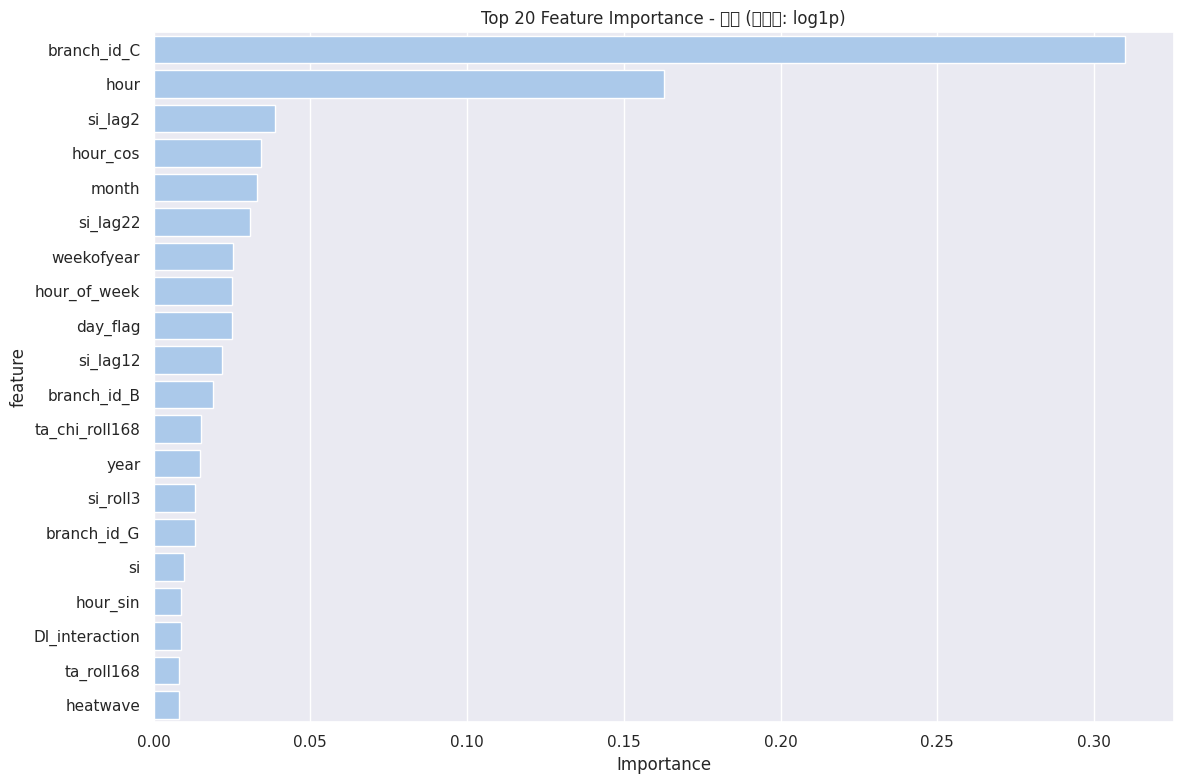


6. 최종 예측을 수행하고 있습니다 (가중치: log1p)...
테스트 데이터로 예측을 수행하고 있습니다...

=== 파이프라인 완료! ===
예측 개수: 8784
선택된 피처 개수: 82
교차검증 평균 RMSE: 14.8128
적용된 가중치 방법: log1p


In [ ]:
# Summer 데이터 실행
summer_results = run_full_pipeline(
    train_df=cluster_results.get('cluster1_summer'),  # 여름 데이터
    test_df=cluster_results_test.get('cluster1_summer'),
    target_col="heat_demand",
    is_summer=True,  # Summer: reg:absoluteerror 사용
    n_trials=200,     # Optuna 시행 횟수
    n_splits=3,      # CV 폴드 수
    random_state=42
)

In [ ]:
summer_results['predictions']

array([78.74849 , 70.10778 , 63.512997, ..., 84.9988  , 82.81876 ,
       77.620514], dtype=float32)

In [ ]:
summer_results

{'predictions': array([78.74849 , 70.10778 , 63.512997, ..., 84.9988  , 82.81876 ,
        77.620514], dtype=float32),
 'model_artifacts': {'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.6301411350439541, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, gamma=0.18694370838960597,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.014774640873115115,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=10, max_leaves=None,
               min_child_weight=4, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=977, n_jobs=-1,
               num_parallel_tree=None, objective='reg:absoluteerror', ...),
  'encoder': OneHot

In [ ]:
# 예측 결과 가져오기
y_test_pred_summer = summer_results['predictions']
test_df = cluster_results_test.get('cluster1_summer').copy()
test_df['heat_demand_pred'] = y_test_pred_summer

summer = test_df[['tm', 'branch_id', 'heat_demand_pred']].copy()
print("여름 데이터 예측 완료")
print(f"예측 개수: {len(summer)}")

print(f"교차검증 RMSE: {summer_results['cv_metrics']['rmse']:.4f}")
print(f"사용된 피처 개수: {len(summer_results['selected_features'])}")

여름 데이터 예측 완료
예측 개수: 8784
교차검증 RMSE: 14.8128
사용된 피처 개수: 82


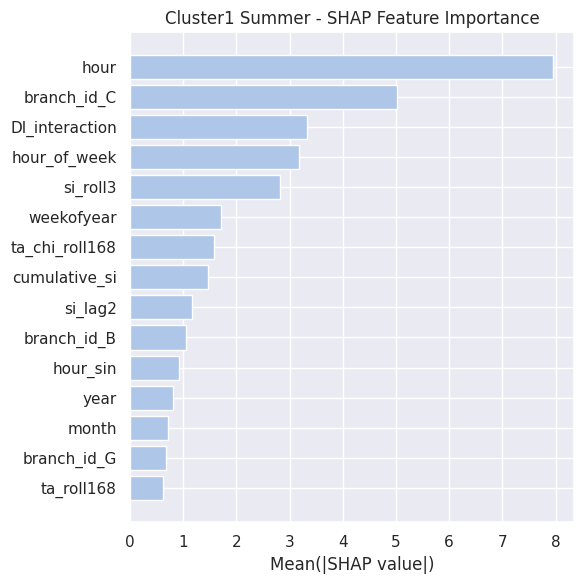

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 모델 및 feature 정보 가져오기
model = summer_results['model_artifacts']['model']
selected_features = summer_results['model_artifacts']['selected_features']
encoder = summer_results['model_artifacts']['encoder']

# train_df 준비
train_df = cluster_results.get('cluster1_summer').copy()
train_df = train_df.sort_values(["branch_id", "tm"]).reset_index(drop=True)

# SHAP용 피처 준비 (prepare_features 활용)
X_train, _, _ = prepare_features(train_df, train_df, target_col='heat_demand', encoder=encoder)
X_train_selected = X_train[selected_features]

# TreeExplainer 생성 및 SHAP 값 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_selected)

# SHAP 값 평균 중요도 계산
mean_shap = np.abs(shap_values).mean(axis=0)

# 중요도 정리
shap_df = pd.DataFrame({
    'Feature': selected_features,
    'MeanAbsSHAP': mean_shap
}).sort_values(by='MeanAbsSHAP', ascending=False).head(15)

# 시각화
plt.figure(figsize=(6, 6))
plt.barh(shap_df['Feature'][::-1], shap_df['MeanAbsSHAP'][::-1], color='#aec7e8')
plt.xlabel('Mean(|SHAP value|)')
plt.title('Cluster1 Summer - SHAP Feature Importance')
plt.tight_layout()
plt.show()

#####  (2) cluster1 - non summer

=== 비여름 데이터 전체 파이프라인 시작 (가중치: log1p) ===

1. 995% 설명력을 갖는 피처를 선택하고 있습니다 (가중치: log1p)...
누적 중요도 99.5%를 갖는 피처를 선택하고 있습니다...
피처 선택 시 log1p 가중치를 적용했습니다.
전체 294개 피처 중 115개 피처를 선택했습니다

2. 선택된 피처로 교차검증을 수행하고 있습니다 (가중치: log1p)...
Fold 1/3 처리 중...
  Fold 1 (가중치: log1p) - RMSE: 48.6477, MAE: 35.9058, R2: 0.9140, MAPE: 10.05%
Fold 2/3 처리 중...
  Fold 2 (가중치: log1p) - RMSE: 38.5417, MAE: 29.3898, R2: 0.9579, MAPE: 12.04%
Fold 3/3 처리 중...


[I 2025-06-27 01:41:57,927] A new study created in memory with name: no-name-3bf200b1-6bdf-45b4-a0e5-fb2310b29b8a


  Fold 3 (가중치: log1p) - RMSE: 30.1009, MAE: 22.8754, R2: 0.9593, MAPE: 13.22%
평균 지표 (가중치: log1p) - RMSE: 39.0967, MAE: 29.3903, R2: 0.9438, MAPE: 11.77%

3. 선택된 피처로 하이퍼파라미터를 최적화하고 있습니다 (가중치: log1p)...
비여름 데이터에 대한 하이퍼파라미터 최적화를 시작합니다 (가중치: log1p)...
목적함수: reg:squarederror


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-06-27 01:42:18,164] Trial 0 finished with value: 39.05622670033728 and parameters: {'n_estimators': 437, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 1.5599452033620265, 'reg_lambda': 0.5808361216819946, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 39.05622670033728.
[I 2025-06-27 01:42:22,970] Trial 1 finished with value: 37.25441353204747 and parameters: {'n_estimators': 737, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 1.8182496720710062, 'reg_lambda': 1.8340450985343382, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 37.25441353204747.
[I 2025-06-27 01:42:27,660] Trial 2 finished with value: 35.958293362924415 and parameters: {'n_estimators': 489, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.65579

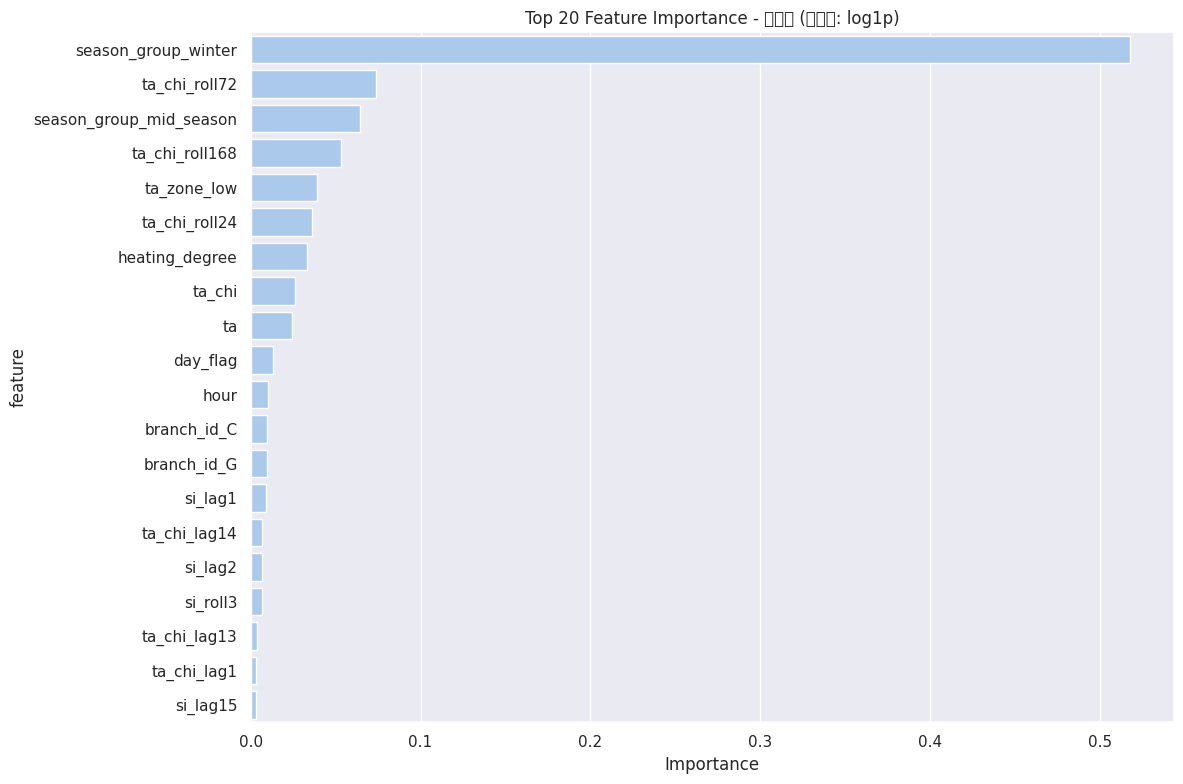


6. 최종 예측을 수행하고 있습니다 (가중치: log1p)...
테스트 데이터로 예측을 수행하고 있습니다...

=== 파이프라인 완료! ===
예측 개수: 17571
선택된 피처 개수: 115
교차검증 평균 RMSE: 39.0967
적용된 가중치 방법: log1p


In [ ]:
# Non-Summer 데이터 실행
non_summer_results = run_full_pipeline(
    train_df=cluster_results.get('cluster1_non_summer'),  # 비여름 데이터
    test_df=cluster_results_test.get('cluster1_non_summer'),
    target_col="heat_demand",
    is_summer=False,  # Non-Summer: reg:squarederror 사용
    n_trials=200,
    n_splits=3,
    random_state=42
)

In [ ]:
non_summer_results

{'predictions': array([476.37634, 440.2979 , 416.2901 , ..., 525.2735 , 518.29944,
        500.73483], dtype=float32),
 'model_artifacts': {'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.749445591829446, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, gamma=4.375099492033362,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.043873642758915754,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=9, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=918, n_jobs=-1,
               num_parallel_tree=None, random_state=42, ...),
  'encoder': OneHotEncoder(handle_unk

In [ ]:
# 예측 결과 가져오기
y_test_pred_non_summer = non_summer_results['predictions']
test_df = cluster_results_test.get('cluster1_non_summer').copy()
test_df['heat_demand_pred'] = y_test_pred_non_summer

non_summer = test_df[['tm', 'branch_id', 'heat_demand_pred']].copy()
print("여름 데이터 예측 완료")
print(f"예측 개수: {len(non_summer)}")

print(f"교차검증 RMSE: {non_summer_results['cv_metrics']['rmse']:.4f}")
print(f"사용된 피처 개수: {len(non_summer_results['selected_features'])}")

여름 데이터 예측 완료
예측 개수: 17571
교차검증 RMSE: 39.0967
사용된 피처 개수: 115


In [ ]:
# cluster1 = pd.concat([summer,non_summer],axis=0)
# cluster1.to_csv('/content/drive/MyDrive/체크난방/0626/0626-cluster1.csv')

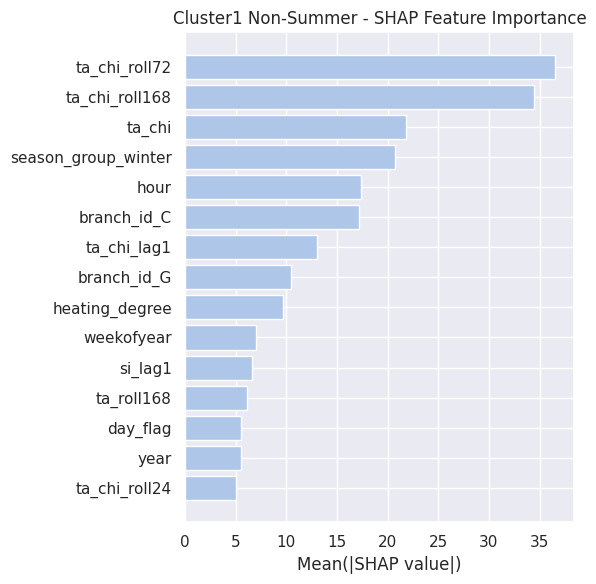

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 모델 및 feature 정보 가져오기
model = non_summer_results['model_artifacts']['model']
selected_features = non_summer_results['model_artifacts']['selected_features']
encoder = non_summer_results['model_artifacts']['encoder']

# train_df 준비
train_df = cluster_results.get('cluster1_non_summer').copy()
train_df = train_df.sort_values(["branch_id", "tm"]).reset_index(drop=True)

# SHAP용 피처 준비 (prepare_features 활용)
X_train, _, _ = prepare_features(train_df, train_df, target_col='heat_demand', encoder=encoder)
X_train_selected = X_train[selected_features]

# TreeExplainer 생성 및 SHAP 값 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_selected)

# SHAP 값 평균 중요도 계산
mean_shap = np.abs(shap_values).mean(axis=0)

# 중요도 정리
shap_df = pd.DataFrame({
    'Feature': selected_features,
    'MeanAbsSHAP': mean_shap
}).sort_values(by='MeanAbsSHAP', ascending=False).head(15)

# 시각화
plt.figure(figsize=(6, 6))
plt.barh(shap_df['Feature'][::-1], shap_df['MeanAbsSHAP'][::-1], color='#aec7e8')
plt.xlabel('Mean(|SHAP value|)')
plt.title('Cluster1 Non-Summer - SHAP Feature Importance')
plt.tight_layout()
plt.show()